# ASL Recognition Training Verification

**Dataset:** `src/Data/processed`  
**Project model family:** transfer learning with `InceptionV3`

## 1. Imports

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, learning_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


I0000 00:00:1776781161.901067    5621 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776781162.389886    5621 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776781165.871938    5621 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Auto-check
import importlib

_required = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "sklearn",
    "tensorflow",
]
missing = [m for m in _required if importlib.util.find_spec(m) is None]
assert not missing, f"Missing packages: {missing}"
print("Auto-check passed.")


Auto-check passed.


## 2. Load image paths and extract features

This mirrors project training setup:
- uses processed hand crops
- uses `299x299` images
- uses `InceptionV3` backbone


In [3]:
DATA_DIR = Path("src/Data/processed")
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
SEED = 42

assert DATA_DIR.exists(), f"Missing dataset directory: {DATA_DIR}"

class_names = sorted([p.name for p in DATA_DIR.iterdir() if p.is_dir()])
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

records = []
for class_name in class_names:
    for img_path in sorted((DATA_DIR / class_name).glob("*")):
        if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            records.append({
                "path": str(img_path),
                "label": class_to_idx[class_name],
                "class_name": class_name,
            })

df = pd.DataFrame(records)
display(df.head())
print(f"Classes: {class_names}")
print(f"Total images: {len(df)}")
display(df["class_name"].value_counts().rename_axis("class").to_frame("count"))


,path,label,class_name
0,src/Data/processed/A/A1.jpg,0,A
1,src/Data/processed/A/A10.jpg,0,A
2,src/Data/processed/A/A1000.jpg,0,A
3,src/Data/processed/A/A1001.jpg,0,A
4,src/Data/processed/A/A1002.jpg,0,A


Classes: ['A', 'B', 'C']
Total images: 6346


,count
class,
B,2202
A,2182
C,1962


In [4]:
def load_and_preprocess_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return preprocess_input(image)


def build_feature_dataset(paths, labels):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, y: (load_and_preprocess_image(p), y), num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


feature_extractor = InceptionV3(
    weights="imagenet",
    include_top=False,
    pooling="avg",
    input_shape=(299, 299, 3),
)

feature_ds = build_feature_dataset(df["path"].values, df["label"].values)
X = feature_extractor.predict(feature_ds, verbose=1)
y = df["label"].to_numpy()

print(f"Embedding matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")


W0000 00:00:1776781167.782181    5621 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


199/199 ━━━━━━━━━━━━━━━━━━━━ 118s 587ms/step
Embedding matrix shape: (6346, 2048)
Target shape: (6346,)


## 3. Why one split is not enough

### Task
- Train using different random train/validation splits
- Observe variability in validation performance

**Reflection**
- Are results stable?


,random_state,accuracy
0,0,1.000000
1,1,1.000000
2,2,0.999475
3,3,0.999475
4,4,0.998950
5,5,0.998424
6,6,0.999475
7,7,1.000000
8,8,0.999475
9,9,0.999475


Mean accuracy: 0.9995
Std accuracy:  0.0005
Min accuracy:  0.9984
Max accuracy:  1.0000


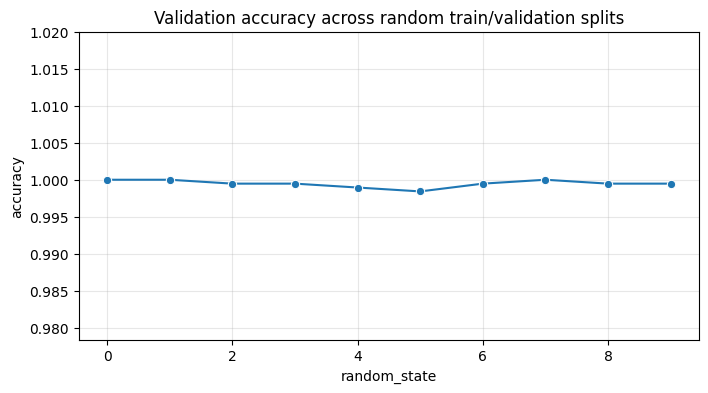

In [5]:
random_states = range(10)
split_scores = []

for seed in random_states:
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=seed
    )

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, random_state=seed)
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    split_scores.append(accuracy_score(y_val, y_pred))

results = pd.DataFrame({
    "random_state": list(random_states),
    "accuracy": split_scores,
})

display(results)
print(f"Mean accuracy: {results['accuracy'].mean():.4f}")
print(f"Std accuracy:  {results['accuracy'].std():.4f}")
print(f"Min accuracy:  {results['accuracy'].min():.4f}")
print(f"Max accuracy:  {results['accuracy'].max():.4f}")

plt.figure(figsize=(8, 4))
sns.lineplot(data=results, x="random_state", y="accuracy", marker="o")
plt.ylim(results["accuracy"].min() - 0.02, results["accuracy"].max() + 0.02)
plt.title("Validation accuracy across random train/validation splits")
plt.grid(True, alpha=0.3)
plt.show()


## 4. Cross-validation

### Task
- Apply stratified K-fold cross-validation
- Compute mean and standard deviation of performance

**Reflection**
- What does variability tell you?


In [6]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, random_state=SEED)
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scores = cross_val_score(model, X, y, cv=cv, scoring="balanced_accuracy")

print("Balanced accuracy per fold:", scores)
print(f"Mean balanced accuracy: {scores.mean():.4f}")
print(f"Std balanced accuracy:  {scores.std():.4f}")


Balanced accuracy per fold: [1.         0.99924242 0.99924414 1.         0.99923547]
Mean balanced accuracy: 0.9995
Std balanced accuracy:  0.0004


## 5. Bias vs variance

### Task
- Compare models of different complexity
- Identify high bias vs high variance behaviour

**Reflection**
- How does model complexity affect train vs validation error?


,model,train_accuracy,val_accuracy,gap
0,Logistic Regression,1.0,1.000000,0.000000
1,Decision Tree,1.0,0.945903,0.054097


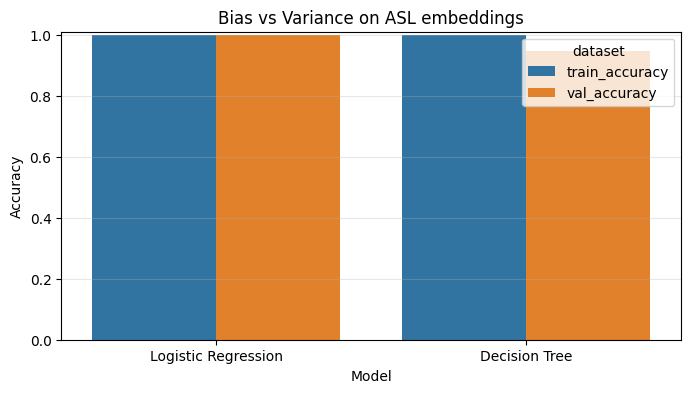

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

models = {
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, random_state=SEED)
    ),
    "Decision Tree": DecisionTreeClassifier(random_state=SEED, max_depth=None),
}

train_scores = []
val_scores = []

for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    train_scores.append(accuracy_score(y_train, y_train_pred))
    val_scores.append(accuracy_score(y_val, y_val_pred))

results = pd.DataFrame({
    "model": list(models.keys()),
    "train_accuracy": train_scores,
    "val_accuracy": val_scores,
})
results["gap"] = results["train_accuracy"] - results["val_accuracy"]

display(results)

plt.figure(figsize=(8, 4))
results_plot = results.melt(
    id_vars="model",
    value_vars=["train_accuracy", "val_accuracy"],
    var_name="dataset",
    value_name="accuracy",
)
sns.barplot(data=results_plot, x="model", y="accuracy", hue="dataset")
plt.title("Bias vs Variance on ASL embeddings")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.0, 1.01)
plt.grid(True, axis="y", alpha=0.3)
plt.show()


## 6. Learning curves

### Task
- Plot learning curves
- Compare training vs validation trends

**Reflection**
- Does model need more data, less complexity, or both?


/home/sleepyy/Desktop/aulas/3ano2sem/IAA/proj_IAA/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/sleepyy/Desktop/aulas/3ano2sem/IAA/proj_IAA/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/sleepyy/Desktop/aulas/3ano2sem/IAA/proj_IAA/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/sleepyy/Desktop/aulas/3ano2sem/IAA/proj_IAA/.venv/lib/python3

,model,train_size,train_mean,val_mean
0,Decision Tree,507,1.000000,0.333333
1,Decision Tree,1649,1.000000,0.333333
2,Decision Tree,2791,0.990935,0.574209
3,Decision Tree,3933,0.987570,0.874263
4,Decision Tree,5076,0.988371,0.939363
5,Logistic Regression,507,NaN,NaN
6,Logistic Regression,1649,NaN,NaN
7,Logistic Regression,2791,1.000000,0.665151
8,Logistic Regression,3933,1.000000,0.995299
9,Logistic Regression,5076,1.000000,0.999544


,model,final_train_score,final_val_score,final_gap
0,Decision Tree,0.988371,0.939363,0.049008
1,Logistic Regression,1.000000,0.999544,0.000456


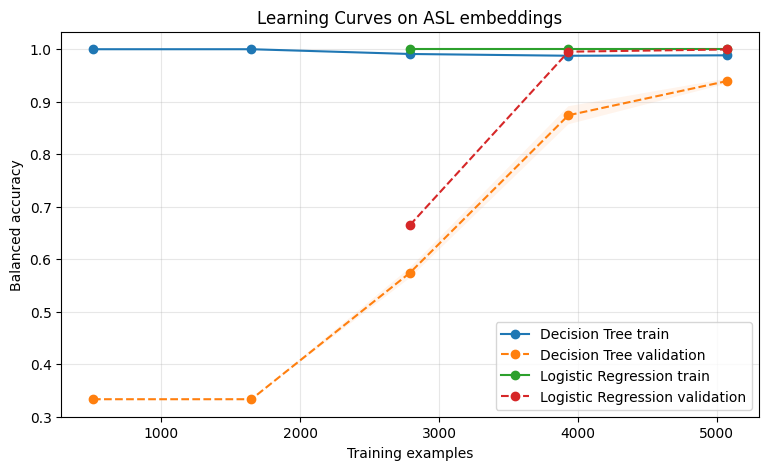

In [8]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=SEED, max_depth=8),
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, random_state=SEED)
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
curve_frames = []
summary_rows = []

plt.figure(figsize=(9, 5))

for model_name, model in models.items():
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        scoring="balanced_accuracy",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=None,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    curve_frames.append(pd.DataFrame({
        "model": model_name,
        "train_size": train_sizes,
        "train_mean": train_mean,
        "val_mean": val_mean,
    }))

    summary_rows.append({
        "model": model_name,
        "final_train_score": train_mean[-1],
        "final_val_score": val_mean[-1],
        "final_gap": train_mean[-1] - val_mean[-1],
    })

    plt.plot(train_sizes, train_mean, marker="o", label=f"{model_name} train")
    plt.plot(train_sizes, val_mean, marker="o", linestyle="--", label=f"{model_name} validation")
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.08)
    plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.08)

curve_results = pd.concat(curve_frames, ignore_index=True)
summary_results = pd.DataFrame(summary_rows)

display(curve_results)
display(summary_results)

plt.title("Learning Curves on ASL embeddings")
plt.xlabel("Training examples")
plt.ylabel("Balanced accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 7. Test saved project model

This section evaluates the actual `.keras` model produced by `src/training_transfer.py`.

Important: do **not** call `preprocess_input` here. The saved project model includes its own `Rescaling` layer, so it expects normal image tensors from `image_dataset_from_directory`.


In [10]:
MODEL_PATH = Path("src/models/base_datasetABC_model.keras")
TEST_DIR = Path("src/Data/split/test")

assert MODEL_PATH.exists(), f"Missing saved model: {MODEL_PATH}"
assert TEST_DIR.exists(), f"Missing test directory: {TEST_DIR}"

saved_model = tf.keras.models.load_model(MODEL_PATH)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=16,
    shuffle=False,
)

test_loss, test_accuracy = saved_model.evaluate(test_ds, verbose=1)

print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")


Found 954 files belonging to 3 classes.


I0000 00:00:1776781450.497185    5722 service.cc:153] XLA service 0x79d0001d6180 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776781450.497210    5722 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1776781450.600193    5722 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776781451.854551    5722 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


60/60 ━━━━━━━━━━━━━━━━━━━━ 26s 322ms/step - accuracy: 0.9969 - loss: 0.0192
Test loss:     0.0192
Test accuracy: 0.9969


              precision    recall  f1-score   support

           A       0.99      1.00      1.00       328
           B       1.00      0.99      1.00       331
           C       1.00      1.00      1.00       295

    accuracy                           1.00       954
   macro avg       1.00      1.00      1.00       954
weighted avg       1.00      1.00      1.00       954



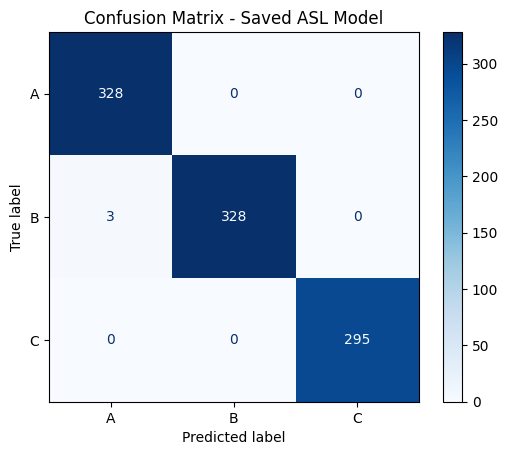

In [11]:
saved_class_names = test_ds.class_names
y_true = []
y_pred = []

for images, labels in test_ds:
    probabilities = saved_model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

print(classification_report(y_true, y_pred, target_names=saved_class_names))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=saved_class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Saved ASL Model")
plt.show()
